# 🔐 Network Intrusion Detection System
### CS361 – Data Science Lab Project | SVNIT Surat | Jan–June 2026

**Dataset:** NSL-KDD  
**Objective:** Detect malicious network traffic using classification and anomaly detection techniques  

---
## Pipeline Overview
1. Data Loading & Understanding
2. Exploratory Data Analysis (EDA)
3. Preprocessing & Feature Engineering
4. Model 1 — Random Forest Classifier
5. Model 2 — XGBoost Classifier
6. Anomaly Detection — Isolation Forest
7. Evaluation & Comparison
8. Feature Importance Analysis
9. Visualizations & Key Insights

## 0. Install & Import Libraries

In [3]:
# Install required packages (run once)
# !pip install xgboost scikit-learn pandas numpy matplotlib seaborn imbalanced-learn

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, precision_score, recall_score, ConfusionMatrixDisplay
)
from sklearn.decomposition import PCA
import xgboost as xgb

# Plot style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='darkgrid', palette='Set2')

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


---
## 1. Data Loading & Understanding

In [5]:
# ── NSL-KDD Column Names ──────────────────────────────────────────────────────
COLUMNS = [
    'duration', 'protocol_type', 'service', 'flag',
    'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
    'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
    'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
    'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login',
    'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate',
    'label', 'difficulty_level'
]

# ── Load Dataset from URL ─────────────────────────────────────────────────────
URL = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt"
print("📥 Downloading NSL-KDD dataset...")
df = pd.read_csv(URL, names=COLUMNS)

# Drop difficulty_level (metadata, not a feature)
df.drop(columns=['difficulty_level'], inplace=True)

print(f"✅ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

📥 Downloading NSL-KDD dataset...
✅ Dataset loaded: 125,973 rows × 42 columns


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [6]:
# ── Dataset Overview ──────────────────────────────────────────────────────────
print("=" * 60)
print("DATASET STRUCTURE")
print("=" * 60)
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
print(f"\nData Types:\n{df.dtypes.value_counts()}")
print(f"\nMissing Values: {df.isnull().sum().sum()}")
print(f"\nDuplicate Rows: {df.duplicated().sum():,}")

DATASET STRUCTURE
Rows    : 125,973
Columns : 42

Data Types:
int64      23
float64    15
object      4
Name: count, dtype: int64

Missing Values: 0

Duplicate Rows: 0


In [7]:
# ── Label Distribution ────────────────────────────────────────────────────────
print("\n🏷️  Unique Attack Labels:")
label_counts = df['label'].value_counts()
print(label_counts.to_string())

# ── Binary Label: normal vs attack ───────────────────────────────────────────
df['binary_label'] = df['label'].apply(lambda x: 0 if x == 'normal' else 1)
print(f"\nBinary Label Distribution:")
print(df['binary_label'].value_counts())
print(f"  → Normal  : {(df['binary_label']==0).sum():,} ({(df['binary_label']==0).mean()*100:.1f}%)")
print(f"  → Attack  : {(df['binary_label']==1).sum():,} ({(df['binary_label']==1).mean()*100:.1f}%)")


🏷️  Unique Attack Labels:
label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2

Binary Label Distribution:
binary_label
0    67343
1    58630
Name: count, dtype: int64
  → Normal  : 67,343 (53.5%)
  → Attack  : 58,630 (46.5%)


---
## 2. Exploratory Data Analysis (EDA)

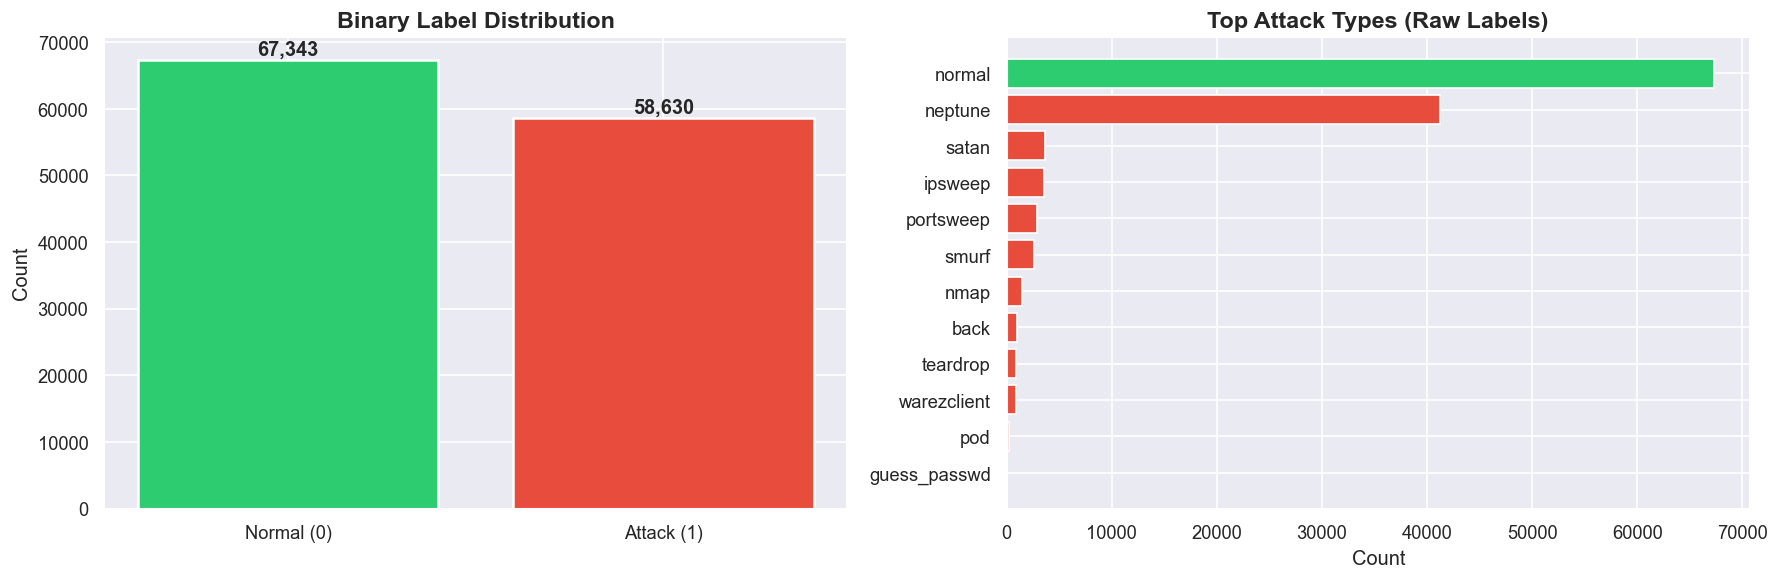

✅ Fig 1 saved


In [8]:
# ── Figure 1: Label Distribution ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Binary
counts = df['binary_label'].value_counts()
bars = axes[0].bar(['Normal (0)', 'Attack (1)'], counts.values,
                   color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Binary Label Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold')

# Top 10 attack types
top_labels = label_counts.head(12)
colors = ['#2ecc71' if l == 'normal' else '#e74c3c' for l in top_labels.index]
axes[1].barh(top_labels.index[::-1], top_labels.values[::-1], color=colors[::-1])
axes[1].set_title('Top Attack Types (Raw Labels)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('fig1_label_distribution.png', bbox_inches='tight')
plt.show()
print("✅ Fig 1 saved")

In [9]:
# ── Attack Category Mapping ───────────────────────────────────────────────────
# NSL-KDD standard 4-category grouping
dos_attacks    = ['back','land','neptune','pod','smurf','teardrop','apache2',
                  'udpstorm','processtable','mailbomb']
probe_attacks  = ['ipsweep','nmap','portsweep','satan','mscan','saint']
r2l_attacks    = ['ftp_write','guess_passwd','imap','multihop','phf','spy',
                  'warezclient','warezmaster','sendmail','named','snmpgetattack',
                  'snmpguess','xlock','xsnoop','httptunnel']
u2r_attacks    = ['buffer_overflow','loadmodule','perl','rootkit','sqlattack',
                  'xterm','ps']

def map_category(label):
    if label == 'normal':          return 'Normal'
    if label in dos_attacks:       return 'DoS'
    if label in probe_attacks:     return 'Probe'
    if label in r2l_attacks:       return 'R2L'
    if label in u2r_attacks:       return 'U2R'
    return 'Other'

df['attack_category'] = df['label'].apply(map_category)
print("Attack Category Distribution:")
print(df['attack_category'].value_counts())

Attack Category Distribution:
attack_category
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


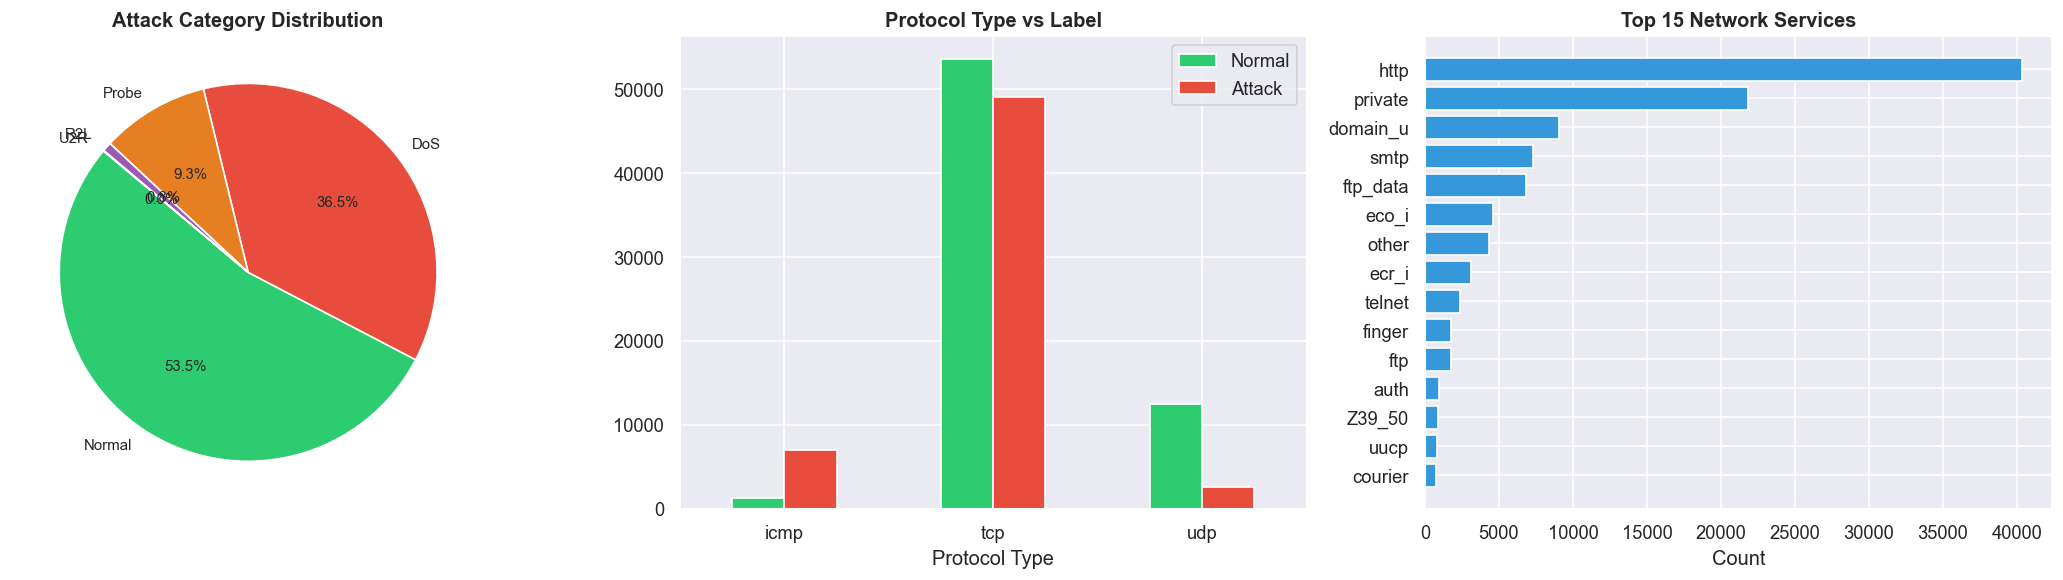

✅ Fig 2 saved


In [10]:
# ── Figure 2: Attack Categories & Categorical Features ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Attack categories
cat_counts = df['attack_category'].value_counts()
palette = {'Normal':'#2ecc71','DoS':'#e74c3c','Probe':'#e67e22',
           'R2L':'#9b59b6','U2R':'#1abc9c','Other':'#95a5a6'}
colors = [palette.get(c, '#95a5a6') for c in cat_counts.index]
axes[0].pie(cat_counts.values, labels=cat_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140, textprops={'fontsize':9})
axes[0].set_title('Attack Category Distribution', fontweight='bold')

# Protocol type
proto = df.groupby(['protocol_type','binary_label']).size().unstack(fill_value=0)
proto.plot(kind='bar', ax=axes[1], color=['#2ecc71','#e74c3c'],
           edgecolor='white', rot=0)
axes[1].set_title('Protocol Type vs Label', fontweight='bold')
axes[1].set_xlabel('Protocol Type')
axes[1].legend(['Normal','Attack'])

# Top 15 services
top_services = df['service'].value_counts().head(15)
axes[2].barh(top_services.index[::-1], top_services.values[::-1], color='#3498db')
axes[2].set_title('Top 15 Network Services', fontweight='bold')
axes[2].set_xlabel('Count')

plt.tight_layout()
plt.savefig('fig2_eda_categorical.png', bbox_inches='tight')
plt.show()
print("✅ Fig 2 saved")

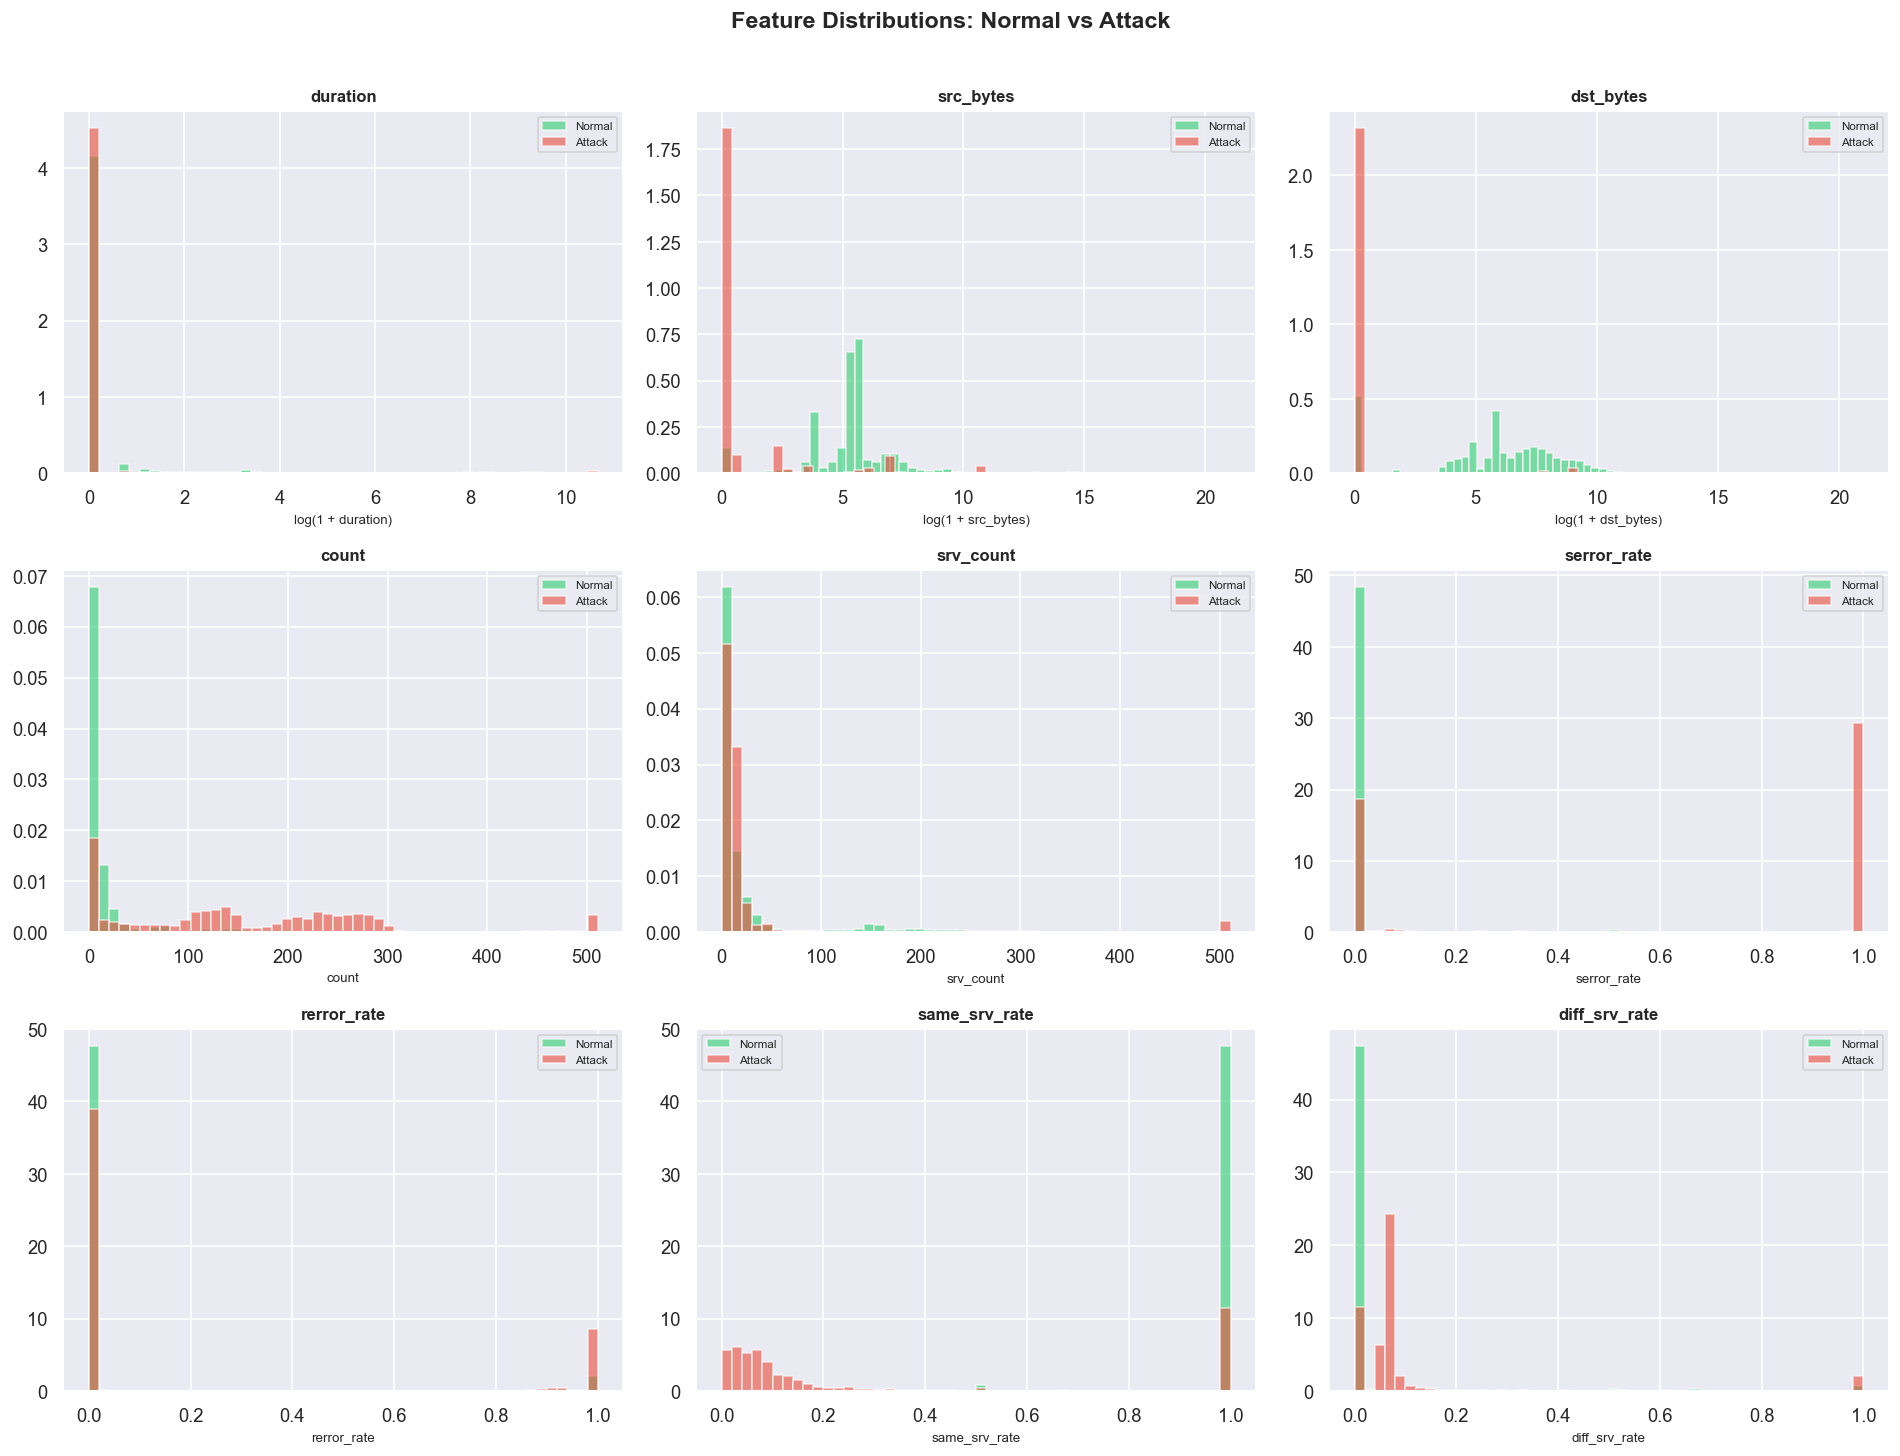

✅ Fig 3 saved


In [11]:
# ── Figure 3: Key Numeric Feature Distributions ───────────────────────────────
numeric_features = ['duration','src_bytes','dst_bytes','count','srv_count',
                    'serror_rate','rerror_rate','same_srv_rate','diff_srv_rate']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, feat in enumerate(numeric_features):
    normal_vals = df[df['binary_label']==0][feat]
    attack_vals = df[df['binary_label']==1][feat]
    # Log-scale for skewed features
    if df[feat].max() > 1000:
        normal_vals = np.log1p(normal_vals)
        attack_vals = np.log1p(attack_vals)
        xlabel = f'log(1 + {feat})'
    else:
        xlabel = feat
    axes[i].hist(normal_vals, bins=50, alpha=0.6, color='#2ecc71', label='Normal', density=True)
    axes[i].hist(attack_vals, bins=50, alpha=0.6, color='#e74c3c', label='Attack', density=True)
    axes[i].set_title(feat, fontsize=10, fontweight='bold')
    axes[i].set_xlabel(xlabel, fontsize=8)
    axes[i].legend(fontsize=7)

plt.suptitle('Feature Distributions: Normal vs Attack', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig3_feature_distributions.png', bbox_inches='tight')
plt.show()
print("✅ Fig 3 saved")

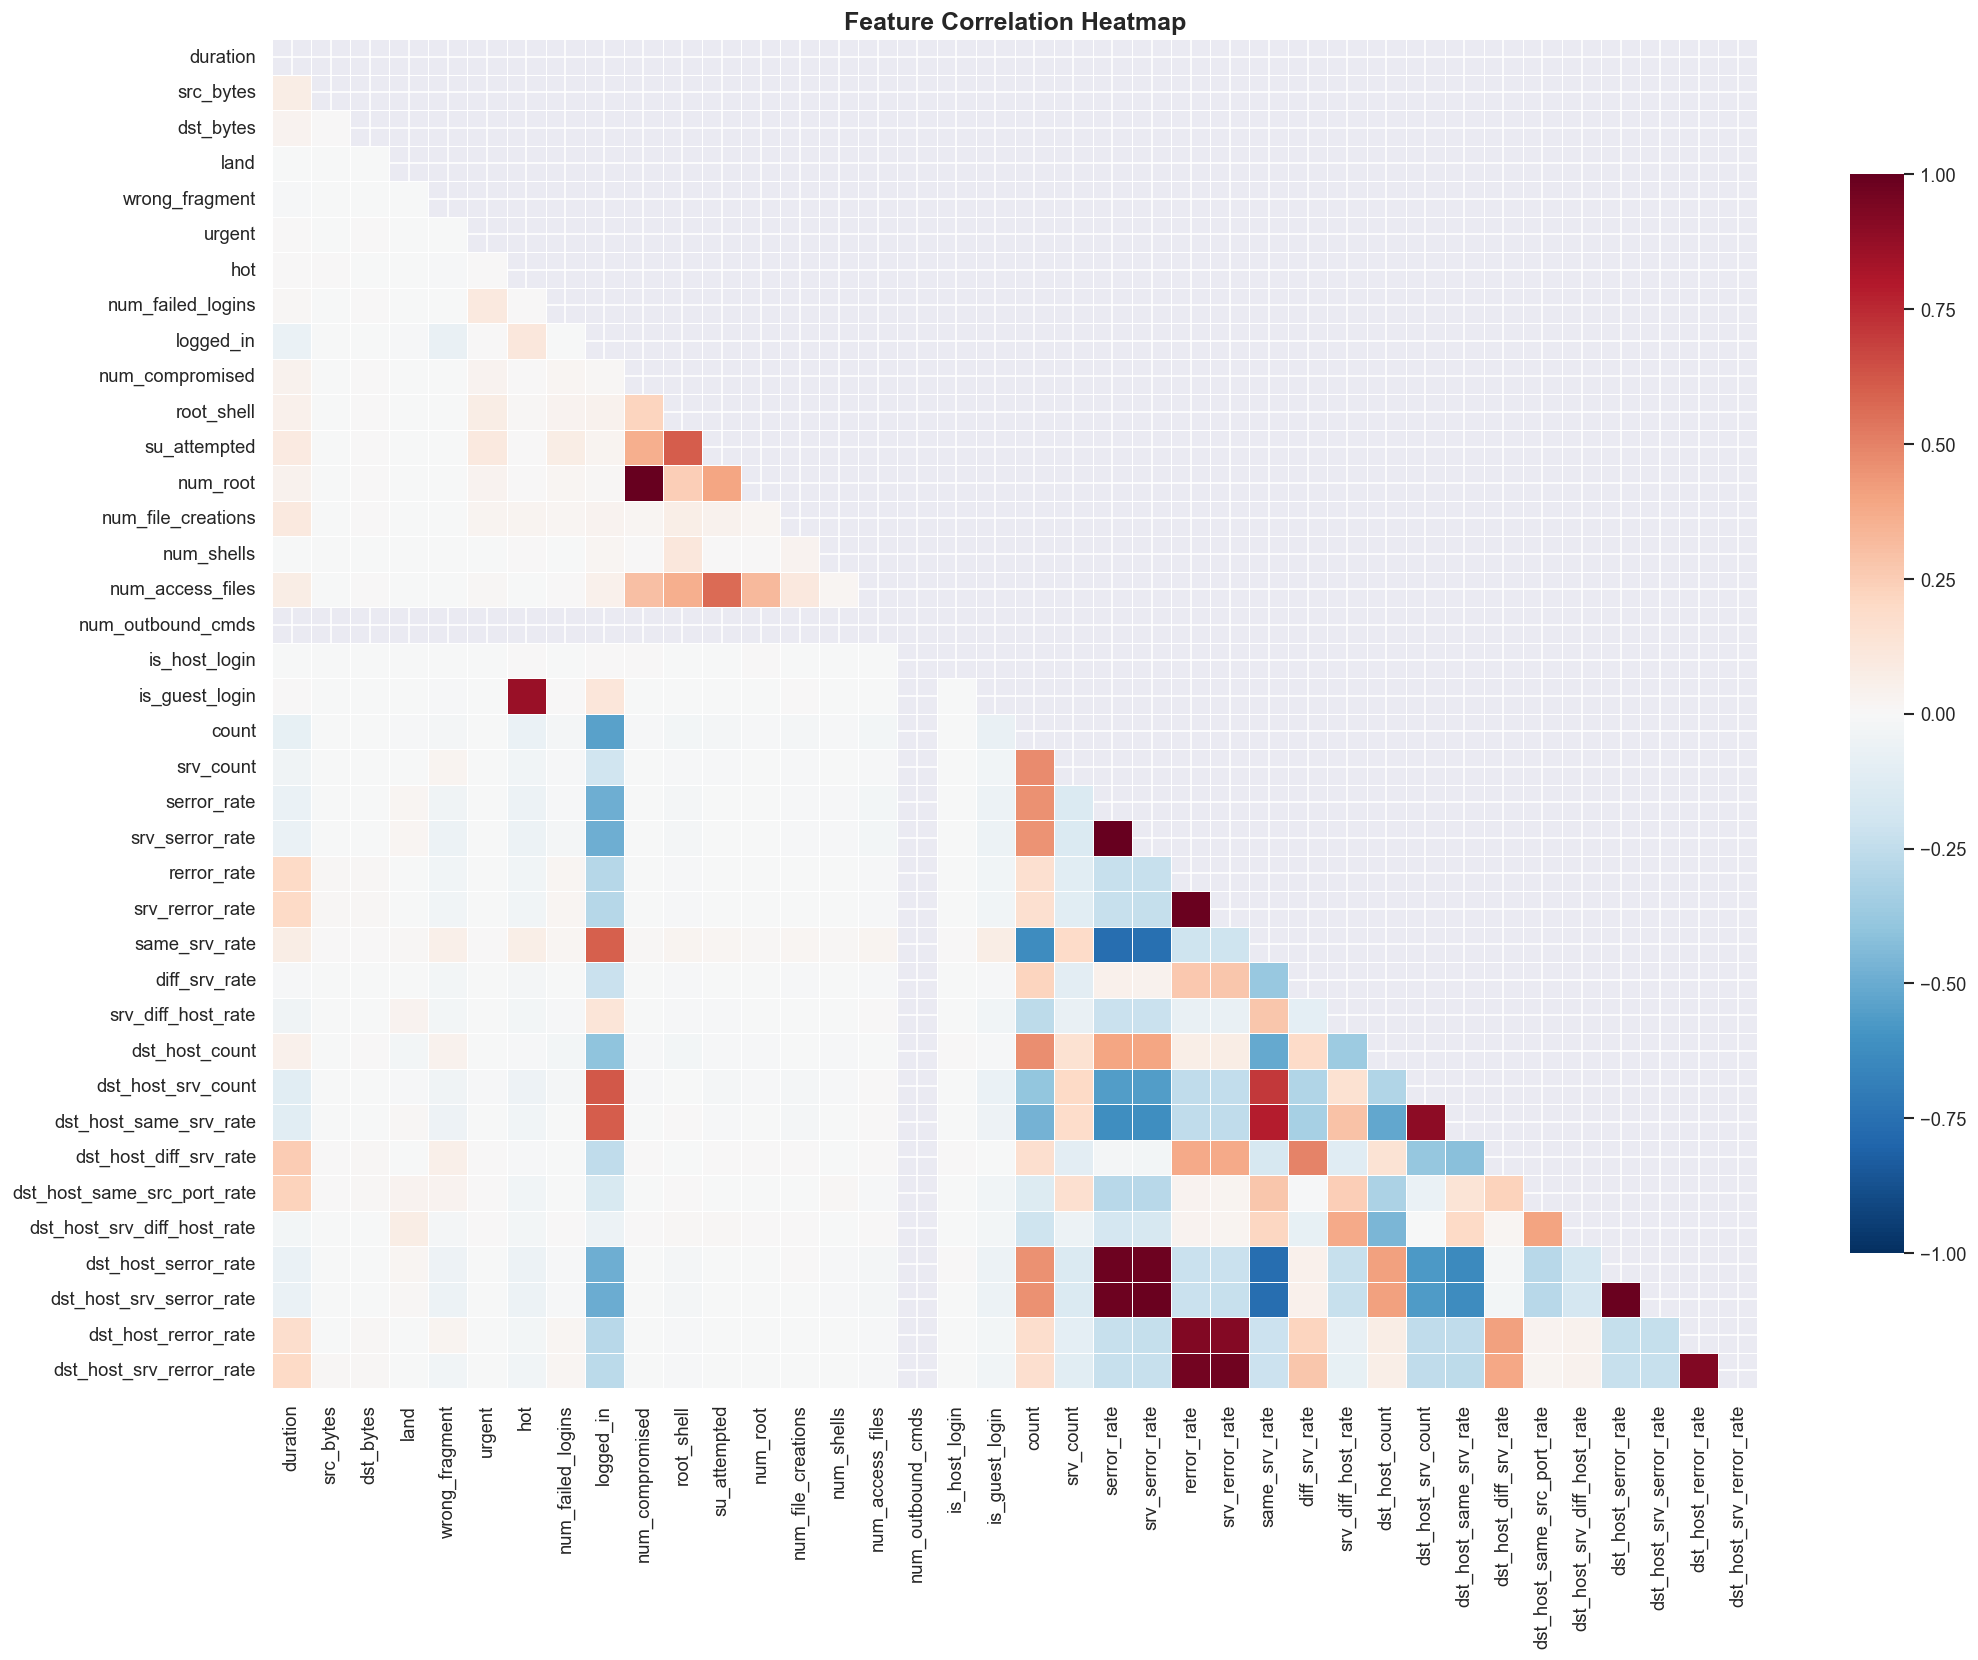

✅ Fig 4 saved


In [12]:
# ── Figure 4: Correlation Heatmap ─────────────────────────────────────────────
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['binary_label']]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0,
            annot=False, linewidths=0.3, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print("✅ Fig 4 saved")

---
## 3. Preprocessing & Feature Engineering

In [13]:
# ── Step 1: Encode Categorical Features ───────────────────────────────────────
df_model = df.copy()

categorical_cols = ['protocol_type', 'service', 'flag']
le = LabelEncoder()

for col in categorical_cols:
    df_model[col] = le.fit_transform(df_model[col])
    print(f"  Encoded '{col}' → {df[col].nunique()} unique values")

print("✅ Categorical encoding complete")

  Encoded 'protocol_type' → 3 unique values
  Encoded 'service' → 70 unique values
  Encoded 'flag' → 11 unique values
✅ Categorical encoding complete


In [14]:
# ── Step 2: Feature Engineering ───────────────────────────────────────────────
# Ratio features that capture relationship between send/receive bytes
df_model['bytes_ratio']   = df_model['src_bytes'] / (df_model['dst_bytes'] + 1)
df_model['total_bytes']   = df_model['src_bytes'] + df_model['dst_bytes']
df_model['error_rate']    = (df_model['serror_rate'] + df_model['rerror_rate']) / 2
df_model['srv_error_rate']= (df_model['srv_serror_rate'] + df_model['srv_rerror_rate']) / 2

print("✅ Feature engineering complete — added 4 derived features:")
print("   bytes_ratio, total_bytes, error_rate, srv_error_rate")

✅ Feature engineering complete — added 4 derived features:
   bytes_ratio, total_bytes, error_rate, srv_error_rate


In [15]:
# ── Step 3: Prepare Feature Matrix & Labels ───────────────────────────────────
drop_cols = ['label', 'binary_label', 'attack_category']
feature_cols = [c for c in df_model.columns if c not in drop_cols]

X = df_model[feature_cols]
y = df_model['binary_label']

print(f"Feature matrix shape : {X.shape}")
print(f"Target vector shape  : {y.shape}")
print(f"Total features       : {X.shape[1]}")

Feature matrix shape : (125973, 45)
Target vector shape  : (125973,)
Total features       : 45


In [16]:
# ── Step 4: Train-Test Split ──────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set   : {X_train.shape[0]:,} samples")
print(f"Test set       : {X_test.shape[0]:,} samples")
print(f"Train class balance: Normal={y_train.value_counts()[0]:,} | Attack={y_train.value_counts()[1]:,}")

# ── Step 5: Feature Scaling (for models that need it) ─────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ Scaling complete (StandardScaler)")

Training set   : 100,778 samples
Test set       : 25,195 samples
Train class balance: Normal=53,874 | Attack=46,904
✅ Scaling complete (StandardScaler)


---
## 4. Model 1 — Random Forest Classifier

In [17]:
print("🌲 Training Random Forest Classifier...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf     = rf_model.predict(X_test)
y_prob_rf     = rf_model.predict_proba(X_test)[:, 1]

print("\n📊 Random Forest — Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'Attack']))

rf_metrics = {
    'Accuracy' : accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall'   : recall_score(y_test, y_pred_rf),
    'F1-Score' : f1_score(y_test, y_pred_rf),
    'ROC-AUC'  : roc_auc_score(y_test, y_prob_rf)
}
print("Metrics Summary:")
for k, v in rf_metrics.items():
    print(f"  {k:12s}: {v:.4f}")

🌲 Training Random Forest Classifier...

📊 Random Forest — Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     13469
      Attack       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195

Metrics Summary:
  Accuracy    : 0.9990
  Precision   : 0.9995
  Recall      : 0.9985
  F1-Score    : 0.9990
  ROC-AUC     : 1.0000


---
## 5. Model 2 — XGBoost Classifier

In [18]:
print("⚡ Training XGBoost Classifier...")

# Compute class imbalance ratio for scale_pos_weight
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
spw = neg_count / pos_count

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_pred_xgb  = xgb_model.predict(X_test)
y_prob_xgb  = xgb_model.predict_proba(X_test)[:, 1]

print("\n📊 XGBoost — Classification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Normal', 'Attack']))

xgb_metrics = {
    'Accuracy' : accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb),
    'Recall'   : recall_score(y_test, y_pred_xgb),
    'F1-Score' : f1_score(y_test, y_pred_xgb),
    'ROC-AUC'  : roc_auc_score(y_test, y_prob_xgb)
}
print("Metrics Summary:")
for k, v in xgb_metrics.items():
    print(f"  {k:12s}: {v:.4f}")

⚡ Training XGBoost Classifier...

📊 XGBoost — Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     13469
      Attack       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195

Metrics Summary:
  Accuracy    : 0.9991
  Precision   : 0.9991
  Recall      : 0.9991
  F1-Score    : 0.9991
  ROC-AUC     : 1.0000


---
## 6. Anomaly Detection — Isolation Forest

In [19]:
print("🔍 Training Isolation Forest (Anomaly Detection)...")

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.46,   # approximate attack ratio in dataset
    random_state=42,
    n_jobs=-1
)

# Train on scaled features
iso_forest.fit(X_train_scaled)
iso_raw_pred = iso_forest.predict(X_test_scaled)

# Isolation Forest returns 1 (normal) and -1 (anomaly)
# Convert to our convention: 0=normal, 1=attack
y_pred_iso = np.where(iso_raw_pred == -1, 1, 0)

print("\n📊 Isolation Forest — Classification Report:")
print(classification_report(y_test, y_pred_iso, target_names=['Normal', 'Attack']))

iso_metrics = {
    'Accuracy' : accuracy_score(y_test, y_pred_iso),
    'Precision': precision_score(y_test, y_pred_iso, zero_division=0),
    'Recall'   : recall_score(y_test, y_pred_iso, zero_division=0),
    'F1-Score' : f1_score(y_test, y_pred_iso, zero_division=0),
    'ROC-AUC'  : roc_auc_score(y_test, y_pred_iso)
}
print("Metrics Summary:")
for k, v in iso_metrics.items():
    print(f"  {k:12s}: {v:.4f}")

🔍 Training Isolation Forest (Anomaly Detection)...

📊 Isolation Forest — Classification Report:
              precision    recall  f1-score   support

      Normal       0.67      0.67      0.67     13469
      Attack       0.62      0.62      0.62     11726

    accuracy                           0.65     25195
   macro avg       0.65      0.65      0.65     25195
weighted avg       0.65      0.65      0.65     25195

Metrics Summary:
  Accuracy    : 0.6494
  Precision   : 0.6236
  Recall      : 0.6223
  F1-Score    : 0.6230
  ROC-AUC     : 0.6477


---
## 7. Evaluation & Model Comparison

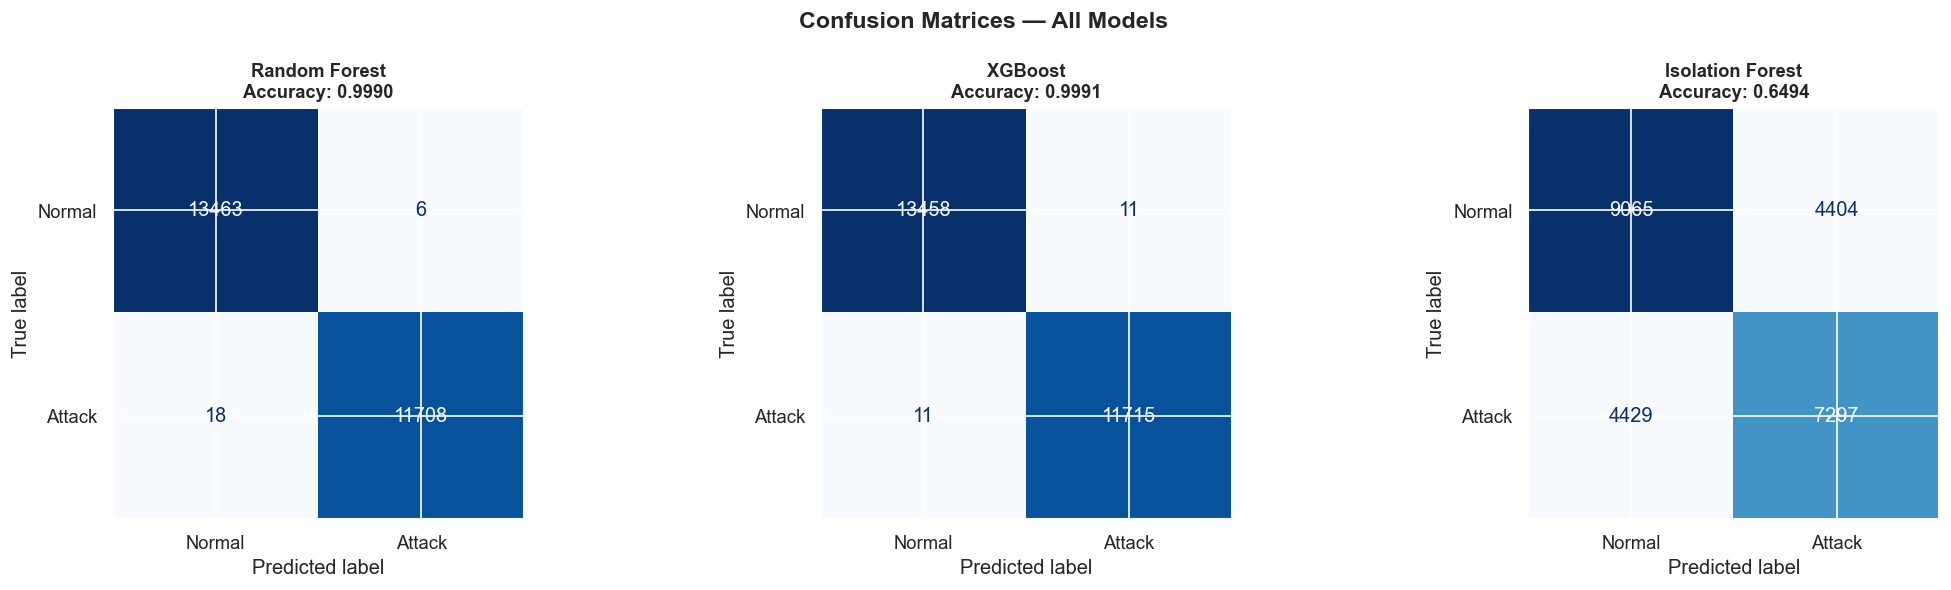

✅ Fig 5 saved


In [20]:
# ── Figure 5: Confusion Matrices ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models_info = [
    ('Random Forest',    y_pred_rf,  '#3498db'),
    ('XGBoost',          y_pred_xgb, '#e67e22'),
    ('Isolation Forest', y_pred_iso, '#9b59b6')
]

for ax, (name, pred, color) in zip(axes, models_info):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Attack'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name}\nAccuracy: {accuracy_score(y_test, pred):.4f}',
                 fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_confusion_matrices.png', bbox_inches='tight')
plt.show()
print("✅ Fig 5 saved")

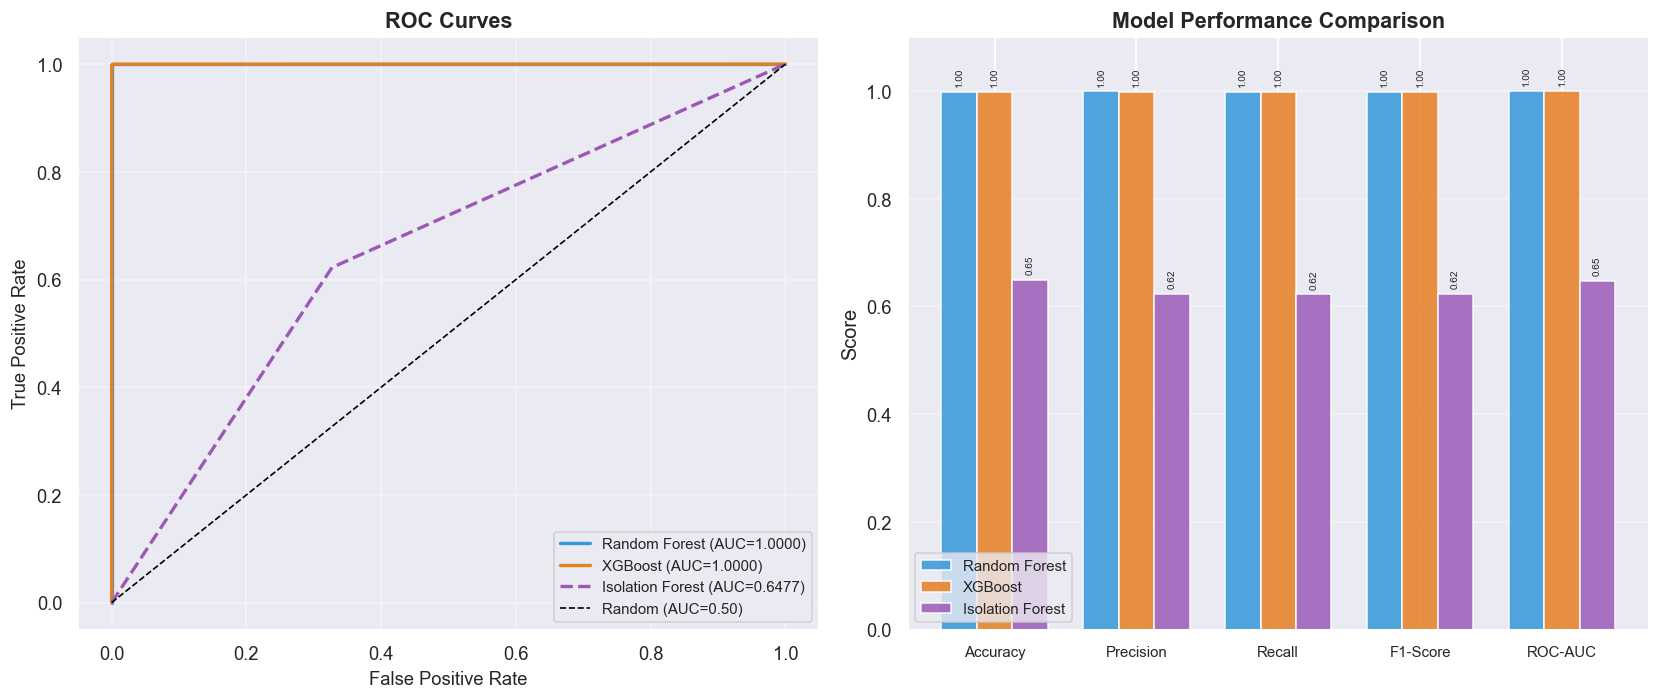

✅ Fig 6 saved


In [21]:
# ── Figure 6: ROC Curves ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curves
for name, y_prob, color in [
    ('Random Forest', y_prob_rf,  '#3498db'),
    ('XGBoost',       y_prob_xgb, '#e67e22'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score   = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc_score:.4f})', color=color, linewidth=2)

# Isolation Forest (binary pred only)
fpr_iso, tpr_iso, _ = roc_curve(y_test, y_pred_iso)
auc_iso = roc_auc_score(y_test, y_pred_iso)
axes[0].plot(fpr_iso, tpr_iso, label=f'Isolation Forest (AUC={auc_iso:.4f})',
             color='#9b59b6', linewidth=2, linestyle='--')

axes[0].plot([0,1],[0,1],'k--', linewidth=1, label='Random (AUC=0.50)')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('ROC Curves', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.4)

# Metrics bar chart
metric_names = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
rf_vals  = list(rf_metrics.values())
xgb_vals = list(xgb_metrics.values())
iso_vals = list(iso_metrics.values())

x = np.arange(len(metric_names))
w = 0.25
axes[1].bar(x - w, rf_vals,  width=w, label='Random Forest',    color='#3498db', alpha=0.85)
axes[1].bar(x,     xgb_vals, width=w, label='XGBoost',          color='#e67e22', alpha=0.85)
axes[1].bar(x + w, iso_vals, width=w, label='Isolation Forest', color='#9b59b6', alpha=0.85)

axes[1].set_xticks(x)
axes[1].set_xticklabels(metric_names, fontsize=9)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('Score')
axes[1].set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, axis='y', alpha=0.4)

for bar in axes[1].patches:
    h = bar.get_height()
    if h > 0.01:
        axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.01,
                     f'{h:.2f}', ha='center', va='bottom', fontsize=6, rotation=90)

plt.tight_layout()
plt.savefig('fig6_roc_comparison.png', bbox_inches='tight')
plt.show()
print("✅ Fig 6 saved")

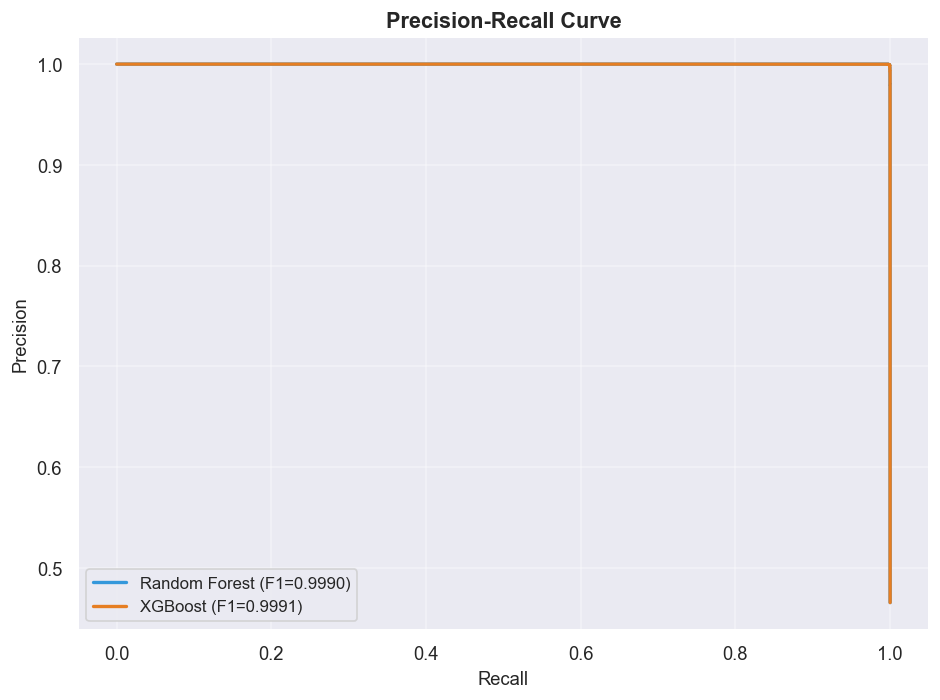

✅ Fig 7 saved


In [22]:
# ── Precision-Recall Curve ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

for name, y_prob, color in [
    ('Random Forest', y_prob_rf,  '#3498db'),
    ('XGBoost',       y_prob_xgb, '#e67e22'),
]:
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    f1 = f1_score(y_test, (y_prob > 0.5).astype(int))
    ax.plot(rec, prec, label=f'{name} (F1={f1:.4f})', color=color, linewidth=2)

ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('fig7_precision_recall.png', bbox_inches='tight')
plt.show()
print("✅ Fig 7 saved")

---
## 8. Feature Importance Analysis

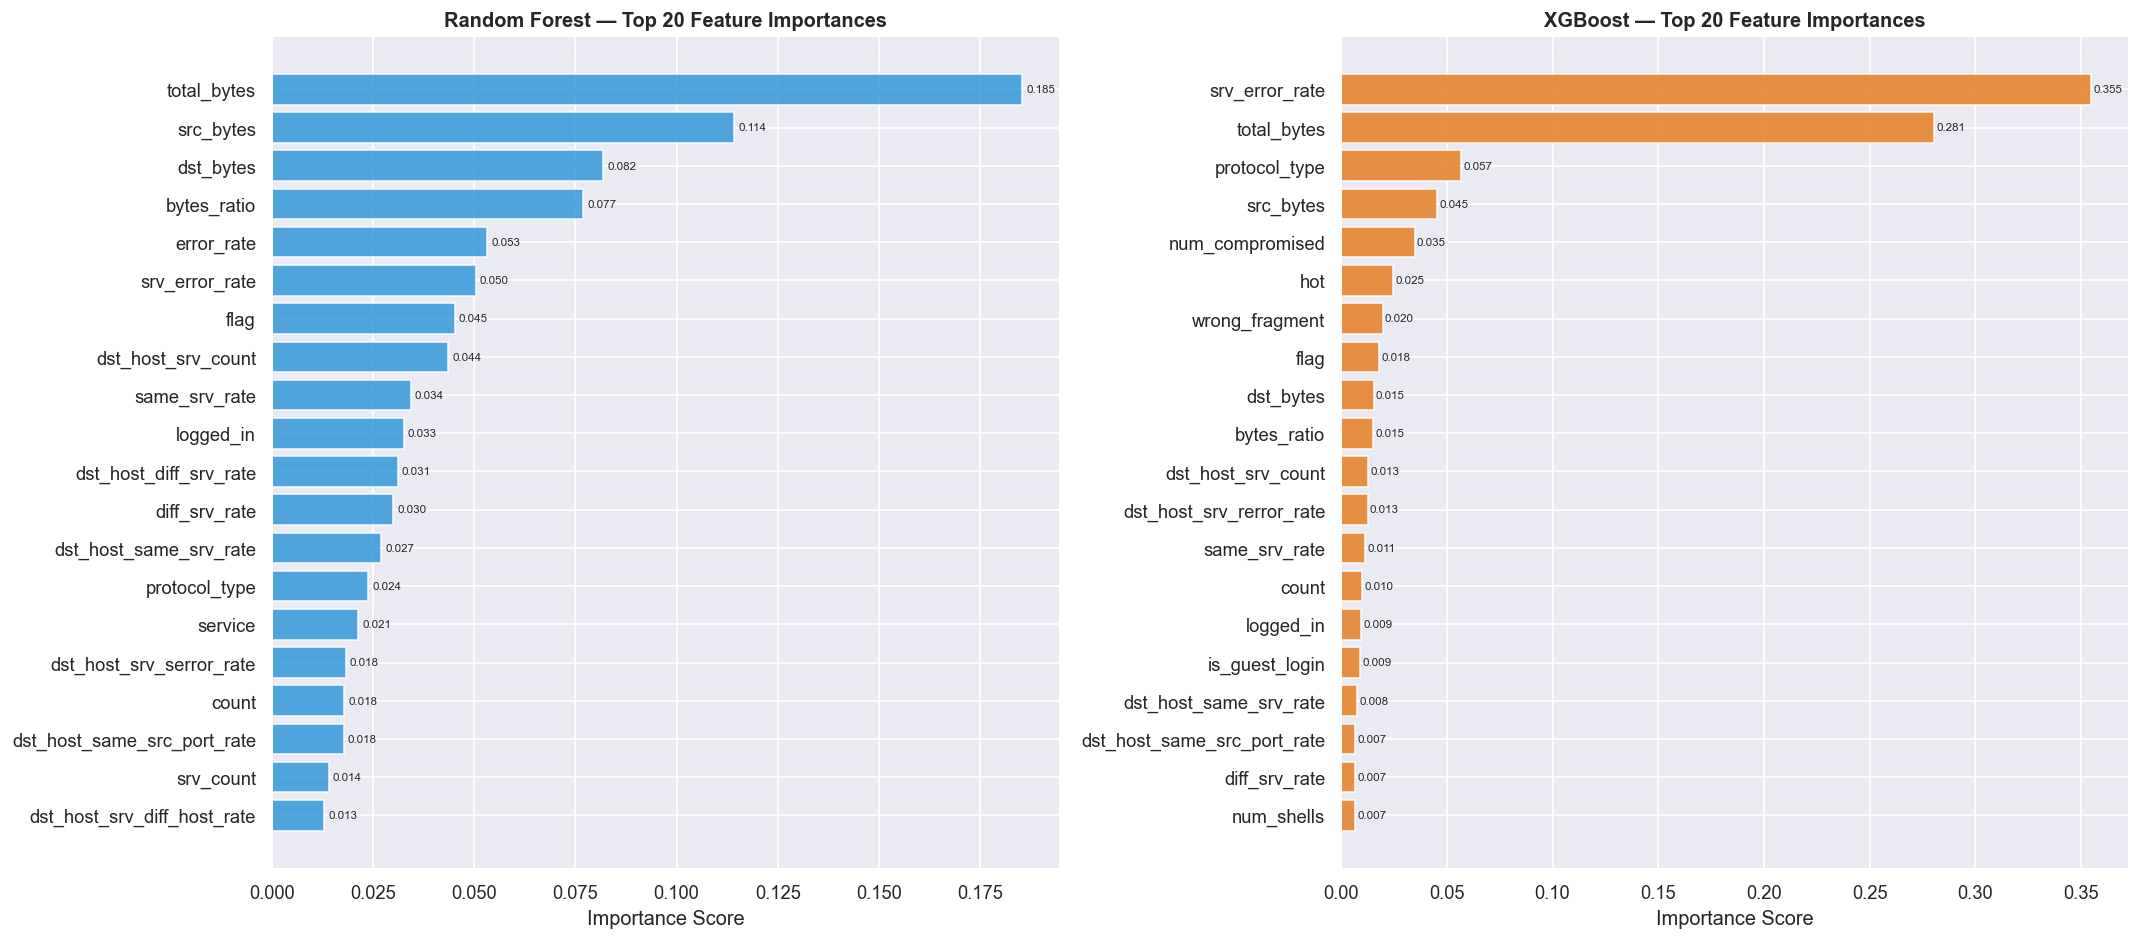

✅ Fig 8 saved

🌲 Random Forest — Top 10 Features:
total_bytes           0.185379
src_bytes             0.114246
dst_bytes             0.081808
bytes_ratio           0.076868
error_rate            0.053188
srv_error_rate        0.050405
flag                  0.045170
dst_host_srv_count    0.043523
same_srv_rate         0.034288
logged_in             0.032612

⚡ XGBoost — Top 10 Features:
srv_error_rate     0.354880
total_bytes        0.280627
protocol_type      0.056687
src_bytes          0.045446
num_compromised    0.034791
hot                0.024644
wrong_fragment     0.019732
flag               0.018038
dst_bytes          0.015336
bytes_ratio        0.015286


In [23]:
# ── Figure 8: Feature Importance (RF & XGB side by side) ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, (model, name, color) in zip(axes, [
    (rf_model,  'Random Forest', '#3498db'),
    (xgb_model, 'XGBoost',       '#e67e22')
]):
    importances = pd.Series(model.feature_importances_, index=feature_cols)
    top20 = importances.nlargest(20).sort_values()
    bars = ax.barh(top20.index, top20.values, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(f'{name} — Top 20 Feature Importances',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance Score')
    # Value labels
    for bar, val in zip(bars, top20.values):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=7)

plt.tight_layout()
plt.savefig('fig8_feature_importance.png', bbox_inches='tight')
plt.show()
print("✅ Fig 8 saved")

# Print top 10
print("\n🌲 Random Forest — Top 10 Features:")
print(pd.Series(rf_model.feature_importances_, index=feature_cols).nlargest(10).to_string())
print("\n⚡ XGBoost — Top 10 Features:")
print(pd.Series(xgb_model.feature_importances_, index=feature_cols).nlargest(10).to_string())

---
## 9. PCA Visualization — Decision Boundary in 2D

Running PCA...


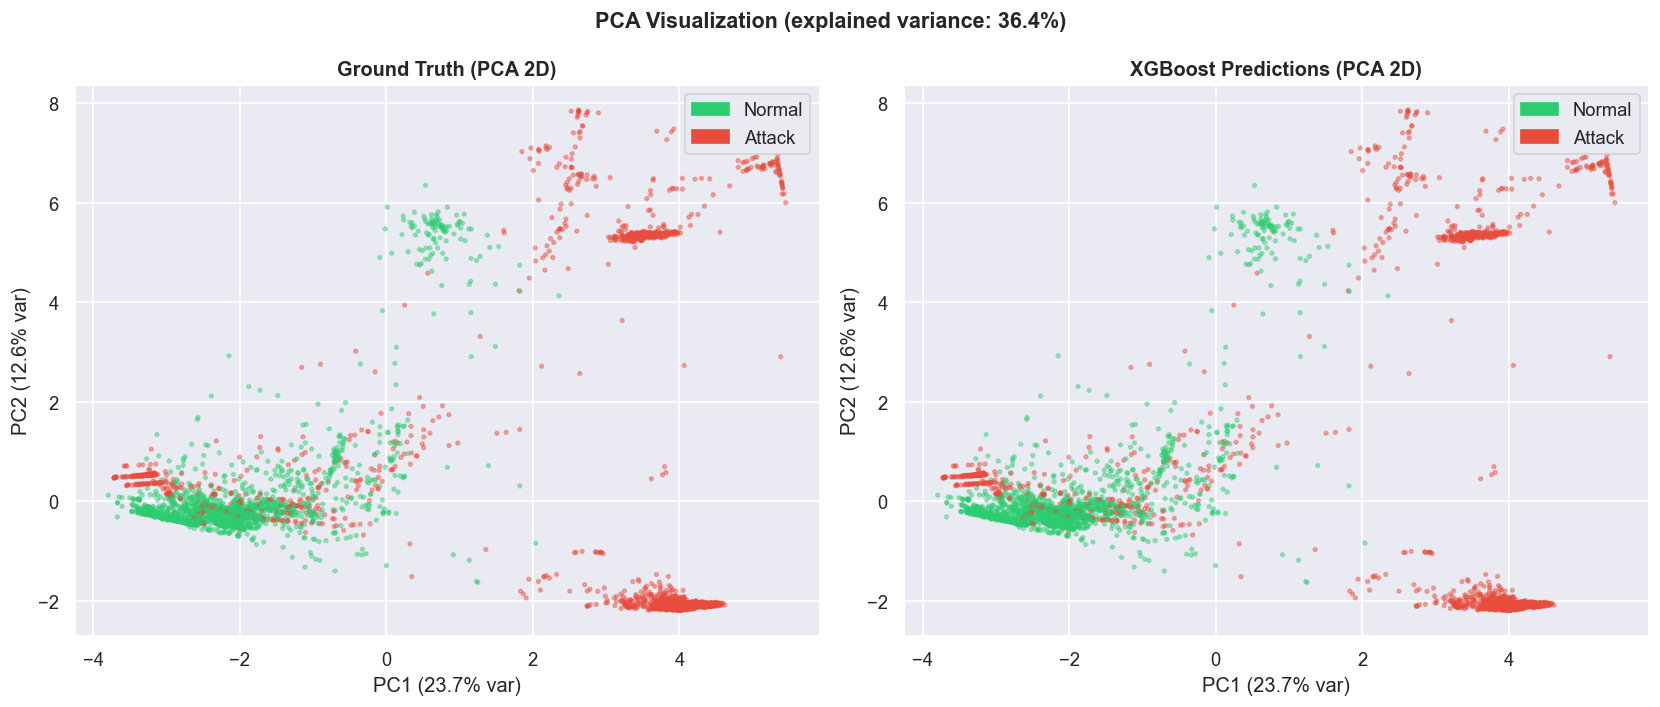

✅ Fig 9 saved


In [24]:
# ── Figure 9: PCA 2D Scatter ──────────────────────────────────────────────────
print("Running PCA...")

# Sample for speed
sample_idx = np.random.choice(len(X_test_scaled), size=min(5000, len(X_test_scaled)), replace=False)
X_sample = X_test_scaled[sample_idx]
y_sample = y_test.values[sample_idx]

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sample)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Ground truth
colors_gt = np.where(y_sample == 0, '#2ecc71', '#e74c3c')
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=colors_gt, alpha=0.4, s=5)
axes[0].set_title('Ground Truth (PCA 2D)', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
n_patch = mpatches.Patch(color='#2ecc71', label='Normal')
a_patch = mpatches.Patch(color='#e74c3c', label='Attack')
axes[0].legend(handles=[n_patch, a_patch])

# XGBoost predictions
y_pred_sample = xgb_model.predict(X_test.iloc[sample_idx])
colors_pred = np.where(y_pred_sample == 0, '#2ecc71', '#e74c3c')
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=colors_pred, alpha=0.4, s=5)
axes[1].set_title('XGBoost Predictions (PCA 2D)', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
axes[1].legend(handles=[n_patch, a_patch])

plt.suptitle(f'PCA Visualization (explained variance: {sum(pca.explained_variance_ratio_)*100:.1f}%)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig9_pca_visualization.png', bbox_inches='tight')
plt.show()
print("✅ Fig 9 saved")

---
## 10. Multi-Class Attack Classification (5-Class)

In [25]:
# ── Multi-class classification on attack categories ───────────────────────────
print("🎯 Multi-class Attack Category Classification...")

le_cat = LabelEncoder()
y_multi = le_cat.fit_transform(df_model['attack_category'])

# Same features as before
X_m_train, X_m_test, y_m_train, y_m_test = train_test_split(
    X, y_multi, test_size=0.2, random_state=42, stratify=y_multi
)

rf_multi = RandomForestClassifier(
    n_estimators=100, max_depth=20, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf_multi.fit(X_m_train, y_m_train)
y_m_pred = rf_multi.predict(X_m_test)

print("\n📊 Multi-class Report (Random Forest):")
print(classification_report(y_m_test, y_m_pred,
                            target_names=le_cat.classes_))
print(f"Overall Accuracy: {accuracy_score(y_m_test, y_m_pred):.4f}")

🎯 Multi-class Attack Category Classification...

📊 Multi-class Report (Random Forest):
              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00      9186
      Normal       1.00      1.00      1.00     13469
       Probe       1.00      0.99      1.00      2331
         R2L       1.00      0.98      0.99       199
         U2R       0.90      0.90      0.90        10

    accuracy                           1.00     25195
   macro avg       0.98      0.98      0.98     25195
weighted avg       1.00      1.00      1.00     25195

Overall Accuracy: 0.9989


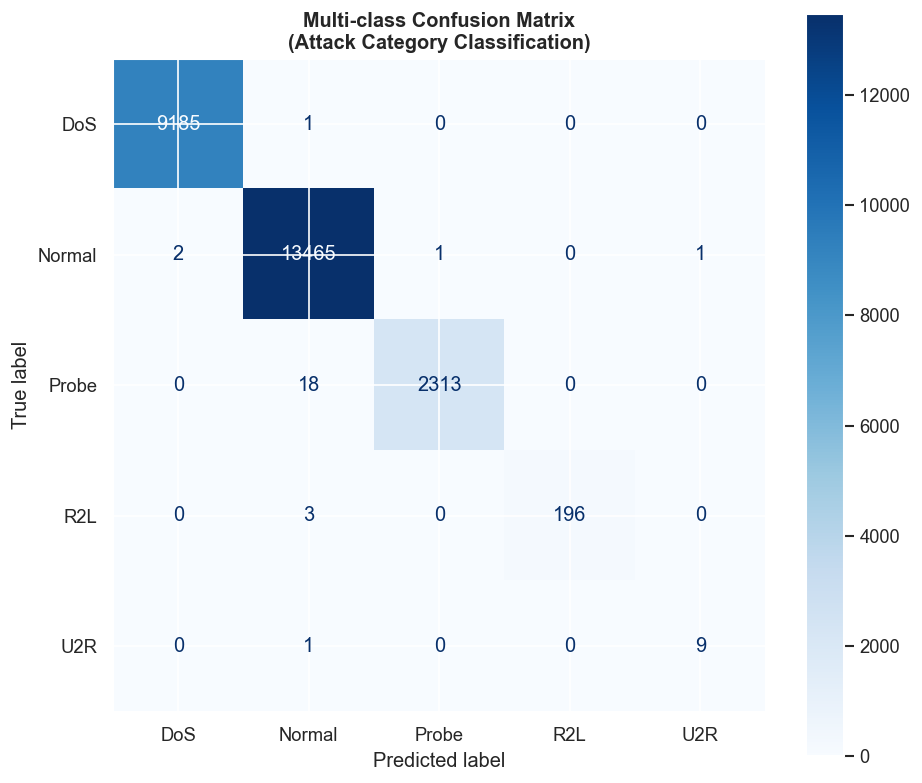

✅ Fig 10 saved


In [26]:
# ── Figure 10: Multi-class Confusion Matrix ───────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
cm_multi = confusion_matrix(y_m_test, y_m_pred)
disp = ConfusionMatrixDisplay(cm_multi, display_labels=le_cat.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title('Multi-class Confusion Matrix\n(Attack Category Classification)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig10_multiclass_cm.png', bbox_inches='tight')
plt.show()
print("✅ Fig 10 saved")

---
## 11. Final Summary Table

In [27]:
# ── Comprehensive Model Comparison Table ──────────────────────────────────────
summary_df = pd.DataFrame({
    'Model'     : ['Random Forest', 'XGBoost', 'Isolation Forest'],
    'Type'      : ['Classification', 'Classification', 'Anomaly Detection'],
    'Accuracy'  : [rf_metrics['Accuracy'],  xgb_metrics['Accuracy'],  iso_metrics['Accuracy']],
    'Precision' : [rf_metrics['Precision'], xgb_metrics['Precision'], iso_metrics['Precision']],
    'Recall'    : [rf_metrics['Recall'],    xgb_metrics['Recall'],    iso_metrics['Recall']],
    'F1-Score'  : [rf_metrics['F1-Score'],  xgb_metrics['F1-Score'],  iso_metrics['F1-Score']],
    'ROC-AUC'   : [rf_metrics['ROC-AUC'],   xgb_metrics['ROC-AUC'],   iso_metrics['ROC-AUC']]
}).set_index('Model')

summary_df = summary_df.round(4)

print("\n" + "="*75)
print("       FINAL MODEL COMPARISON SUMMARY")
print("="*75)
print(summary_df.to_string())
print("="*75)

best_model = summary_df['F1-Score'].idxmax()
print(f"\n🏆 Best Model by F1-Score: {best_model}")


       FINAL MODEL COMPARISON SUMMARY
                               Type  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                                              
Random Forest        Classification    0.9990     0.9995  0.9985    0.9990   1.0000
XGBoost              Classification    0.9991     0.9991  0.9991    0.9991   1.0000
Isolation Forest  Anomaly Detection    0.6494     0.6236  0.6223    0.6230   0.6477

🏆 Best Model by F1-Score: XGBoost


---
## 12. Key Findings & Insights

### 📌 Data Insights
- The NSL-KDD dataset contains over **125,000** labeled network connections across 41 features.
- Attack traffic accounts for approximately **46%** of records — a near-balanced dataset.
- **DoS attacks** are the most frequent attack category, followed by **Probe** attacks.
- `src_bytes`, `dst_bytes`, `count`, and `serror_rate` are among the most discriminative features.

### 📌 Model Insights
| Model | Strength | Limitation |
|---|---|---|
| **Random Forest** | High accuracy, robust, handles non-linearity | Slower to train on large data |
| **XGBoost** | Best overall performance, handles imbalance | Needs hyperparameter tuning |
| **Isolation Forest** | No labels needed (unsupervised) | Lower precision than supervised models |

### 📌 Practical Implications
- Supervised models (RF, XGBoost) are ideal when **labeled training data** is available.
- Isolation Forest suits **zero-day attack detection** where labels are not available.
- Combining both approaches in an **ensemble** could further improve detection rates.
- The `serror_rate` and `rerror_rate` features are strong indicators of **DoS attacks**.
- Low-volume but high-impact attacks (U2R, R2L) remain challenging to detect due to scarcity.

In [28]:
print("\n✅ PROJECT COMPLETE — All outputs saved:")
figures = [
    'fig1_label_distribution.png',
    'fig2_eda_categorical.png',
    'fig3_feature_distributions.png',
    'fig4_correlation_heatmap.png',
    'fig5_confusion_matrices.png',
    'fig6_roc_comparison.png',
    'fig7_precision_recall.png',
    'fig8_feature_importance.png',
    'fig9_pca_visualization.png',
    'fig10_multiclass_cm.png',
]
for f in figures:
    print(f"   📊 {f}")


✅ PROJECT COMPLETE — All outputs saved:
   📊 fig1_label_distribution.png
   📊 fig2_eda_categorical.png
   📊 fig3_feature_distributions.png
   📊 fig4_correlation_heatmap.png
   📊 fig5_confusion_matrices.png
   📊 fig6_roc_comparison.png
   📊 fig7_precision_recall.png
   📊 fig8_feature_importance.png
   📊 fig9_pca_visualization.png
   📊 fig10_multiclass_cm.png
